Connected to lcr-env (3.11.14) (Python 3.11.14)

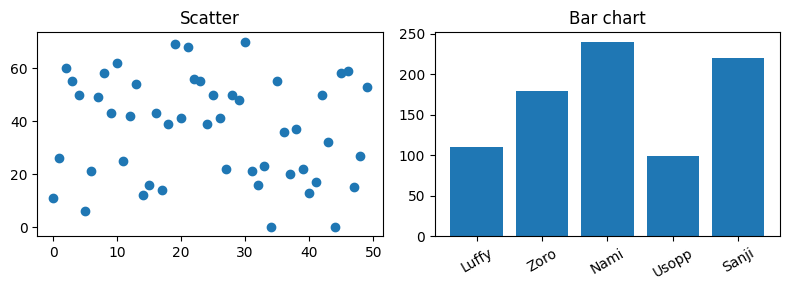

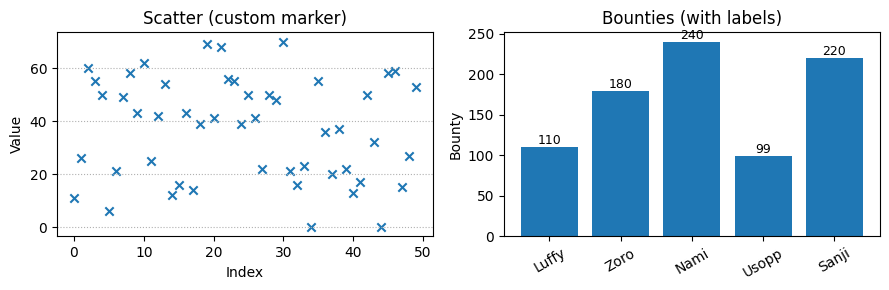

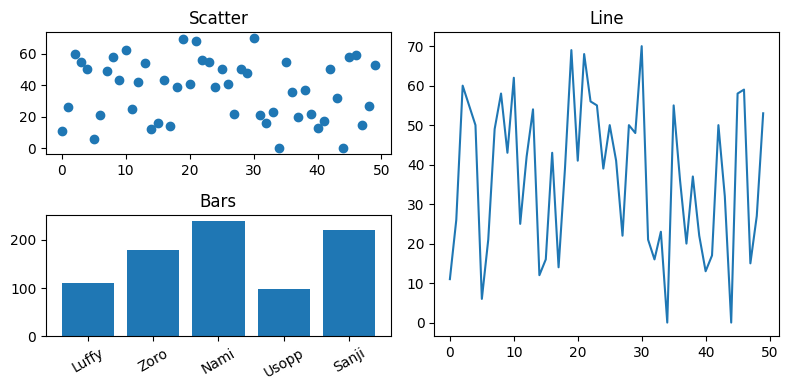

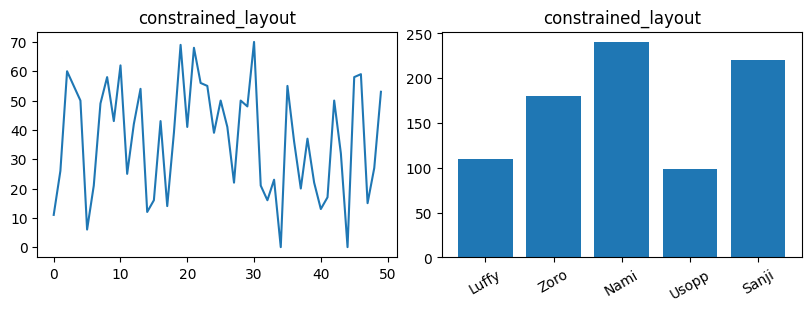

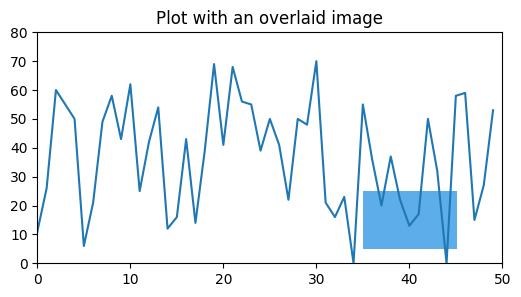

In [ ]:
# # Class 6 — Subplots and Combining Visualizations — Activities & Questions (answers)

# ### Slide 4 — Recall: figure vs axes (subplots)
# - Same concept as before: one figure can contain multiple axes; each axes can be customized independently.

# ### Slide 8 — Activity: customize the subplots
# - Add separate titles, axis labels, and style choices per subplot (e.g., scatter marker shape on left; bar labels/rotation on right).
# - A worked example is included in the Class 6 notebook

# ### Slide 9–10 — Subplot mosaics
# - `subplot_mosaic` lets you lay out axes in an asymmetric grid by naming positions (helpful for dashboards).

# Class 6 — Subplots and Combining Visualizations

# This notebook recreates the in-class subplot examples and completes the customization activity.

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(613)

x1 = np.arange(50)
y1 = np.random.randint(0, 75, 50)

x2 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y2 = np.array([110, 180, 240, 99, 220])

## Two subplots side-by-side (Slides 6–7)
fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(8, 3))

ax1.scatter(x1, y1)
ax1.set_title("Scatter")

ax2.bar(x2, y2)
ax2.set_title("Bar chart")
ax2.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()
## Activity (Slide 8): Customize each subplot differently
fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(9, 3))

# left: scatter with different marker + labels
ax1.scatter(x1, y1, marker="x")
ax1.set_title("Scatter (custom marker)")
ax1.set_xlabel("Index")
ax1.set_ylabel("Value")
ax1.grid(axis="y", linestyle=":")

# right: bar chart with value labels
bars = ax2.bar(x2, y2)
ax2.set_title("Bounties (with labels)")
ax2.set_ylabel("Bounty")
ax2.tick_params(axis="x", rotation=30)

for b in bars:
    ax2.annotate(f"{int(b.get_height())}",
                 (b.get_x() + b.get_width()/2, b.get_height()),
                 ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()
## Subplot mosaic (Slides 9–10)
fig, axd = plt.subplot_mosaic([["ax1", "ax3"],
                                ["ax2", "ax3"]],
                               figsize=(8, 4))

axd["ax1"].scatter(x1, y1)
axd["ax1"].set_title("Scatter")

axd["ax2"].bar(x2, y2)
axd["ax2"].set_title("Bars")
axd["ax2"].tick_params(axis="x", rotation=30)

axd["ax3"].plot(x1, y1)
axd["ax3"].set_title("Line")

plt.tight_layout()
plt.show()
## Layout tuning (tight_layout vs constrained_layout)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True)
ax1.plot(x1, y1)
ax1.set_title("constrained_layout")

ax2.bar(x2, y2)
ax2.tick_params(axis="x", rotation=30)
ax2.set_title("constrained_layout")

plt.show()
## Adding an image to a plot (Slides ~29–33 idea)

# Genererate a tiny synthetic image (no external files needed) and overlay it in the axes.
# Create a small synthetic image

img = np.zeros((20, 20, 3))
img[:, :, 0] = 0.2  # red channel
img[:, :, 1] = 0.6  # green channel
img[:, :, 2] = 0.9  # blue channel

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(x1, y1)
ax.set_title("Plot with an overlaid image")

# Place the image in data coordinates (x from 35 to 45; y from 5 to 25)
ax.imshow(img, extent=(35, 45, 5, 25), aspect="auto", alpha=0.8)
ax.set_xlim(0, 50)
ax.set_ylim(0, 80)

plt.show()